# Notebook17 – RL Robustness & Stress Testing

---

## Goal of Notebook17

Previous notebooks established:

- dynamic cellular-state trajectories
- process-aware interventions
- reinforcement-learning policy optimization
- rollout validation against rule-based controllers

Under nominal conditions, the RL controller outperformed
alternative decision strategies.

However, real bioprocesses are rarely ideal.

Industrial manufacturing environments contain:

- clone-to-clone variability
- process uncertainty
- metabolite accumulation
- quality drift
- assay noise
- unexpected stress events

Therefore, before deployment, the controller must be
evaluated under adverse conditions.

---

## What Notebook17 Tests

We simulate several stress scenarios:

- baseline
- high burden
- high risk
- quality drift
- low productivity
- noisy environment

For each scenario we compare:

- RL controller
- Rule-based controller
- No-action controller

---

## Why This Matters

A controller is useful only if it remains effective
outside the exact conditions used for training.

Notebook17 measures:

- reward robustness
- productivity robustness
- quality robustness
- burden robustness
- failure resistance

The final output is a deployment-readiness assessment
for the learned RL policy.

## Section 1 — Load rollout datasets

Notebook16 generated deployment rollouts for:

- RL controller
- Rule-based controller
- No-action controller

These trajectories represent simulated cellular evolution across pseudo-time.

The rollout dataset becomes the baseline environment used for stress testing.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[0]

rollout_path = (
    ROOT /
    "data/synthetic/digital_twin/" /
    "notebook16_rollout_trajectories_5000_legacy.csv"
)

summary_path = (
    ROOT /
    "data/synthetic/digital_twin/" /
    "notebook16_controller_summary_5000_legacy.csv"
)

rollouts = pd.read_csv(rollout_path)
controller_summary = pd.read_csv(summary_path)

print("Rollout shape:", rollouts.shape)
display(rollouts.head())

Rollout shape: (4140, 10)


,clone_process_id,pseudo_time,controller,action,productivity_state,integrated_burden,stress_failure_risk,galactosylation,sialylation,reward
0,0,0,RL,perfusion_rescue,0.973274,0.543035,0.424725,0.757473,0.634527,0.359662
1,0,1,RL,perfusion_rescue,0.973274,0.493035,0.384725,0.757473,0.634527,0.449662
2,0,2,RL,perfusion_rescue,0.973274,0.443035,0.344725,0.757473,0.634527,0.539662
3,0,3,RL,perfusion_rescue,0.973274,0.393035,0.304725,0.757473,0.634527,0.629662
4,0,4,RL,perfusion_rescue,0.973274,0.343035,0.264725,0.757473,0.634527,0.719662


## Section 2 — Inspect baseline controller performance

Before stress testing, we review baseline controller performance.

This provides a reference point against which robustness will be evaluated.

In [3]:
display(controller_summary)

,controller,reward,productivity_state,integrated_burden,stress_failure_risk,galactosylation
0,No_Action,-0.199,0.067,0.286,0.324,0.707
1,RL,0.094,0.085,0.175,0.171,0.732
2,Rule,0.049,0.263,0.298,0.261,0.707


## Section 3 — Define stress scenarios

Several perturbation scenarios are introduced.

These scenarios represent common challenges encountered during
industrial bioprocessing.

Scenarios include:

- baseline
- high burden
- high stress risk
- quality drift
- low productivity
- noisy environment

Each scenario modifies cellular-state variables differently.

In [4]:
stress_scenarios = {
    "baseline": {},
    "high_burden": {"integrated_burden": 1.30},
    "high_risk": {"stress_failure_risk": 1.40},
    "quality_drift": {"galactosylation": 0.85},
    "low_productivity": {"productivity_state": 0.80},
    "noisy_environment": {"noise": 0.05}
}

stress_scenarios

{'baseline': {},
 'high_burden': {'integrated_burden': 1.3},
 'high_risk': {'stress_failure_risk': 1.4},
 'quality_drift': {'galactosylation': 0.85},
 'low_productivity': {'productivity_state': 0.8},
 'noisy_environment': {'noise': 0.05}}

## Section 4 — Generate perturbed environments

For each stress scenario, rollout trajectories are modified.

This simulates how the same clones might behave under less favorable
process conditions.

In [5]:
scenario_datasets = {}

for scenario, effects in stress_scenarios.items():

    df = rollouts.copy()

    if "integrated_burden" in effects:
        df["integrated_burden"] *= effects["integrated_burden"]

    if "stress_failure_risk" in effects:
        df["stress_failure_risk"] *= effects["stress_failure_risk"]

    if "galactosylation" in effects:
        df["galactosylation"] *= effects["galactosylation"]

    if "productivity_state" in effects:
        df["productivity_state"] *= effects["productivity_state"]

    if "noise" in effects:

        noise = np.random.normal(
            0,
            effects["noise"],
            len(df)
        )

        df["reward"] += noise

    scenario_datasets[scenario] = df

print("Scenarios generated:", len(scenario_datasets))

Scenarios generated: 6


## Section 5 — Evaluate controllers under stress

Controller performance is recalculated under every scenario.

Metrics include:

- reward
- productivity
- burden
- failure risk
- glycosylation quality

These values form the basis of robustness analysis.

In [6]:
controller_results = []

for scenario, df in scenario_datasets.items():

    summary = (
        df
        .groupby("controller")
        .agg(
            reward=("reward","mean"),
            productivity_state=("productivity_state","mean"),
            integrated_burden=("integrated_burden","mean"),
            stress_failure_risk=("stress_failure_risk","mean"),
            galactosylation=("galactosylation","mean"),
            sialylation=("sialylation","mean")
        )
        .reset_index()
    )

    summary["scenario"] = scenario

    controller_results.append(summary)

stress_results = pd.concat(
    controller_results,
    ignore_index=True
)

display(stress_results.head())

,controller,reward,productivity_state,integrated_burden,stress_failure_risk,galactosylation,sialylation,scenario
0,No_Action,-0.198916,0.066783,0.286271,0.323832,0.707286,0.661090,baseline
1,RL,0.094314,0.085044,0.175063,0.170762,0.732146,0.677253,baseline
2,Rule,0.049198,0.263057,0.297510,0.260752,0.707286,0.661090,baseline
3,No_Action,-0.198916,0.066783,0.372153,0.323832,0.707286,0.661090,high_burden
4,RL,0.094314,0.085044,0.227582,0.170762,0.732146,0.677253,high_burden


## Section 6 — Reward robustness

Reward summarizes overall process success.

Higher reward indicates better balance between:

- productivity
- quality
- burden
- process stability

A robust controller should maintain reward across stress scenarios.

controller,No_Action,RL,Rule
scenario,,,
baseline,-0.199,0.094,0.049
high_burden,-0.199,0.094,0.049
high_risk,-0.199,0.094,0.049
low_productivity,-0.199,0.094,0.049
noisy_environment,-0.200,0.096,0.049
quality_drift,-0.199,0.094,0.049


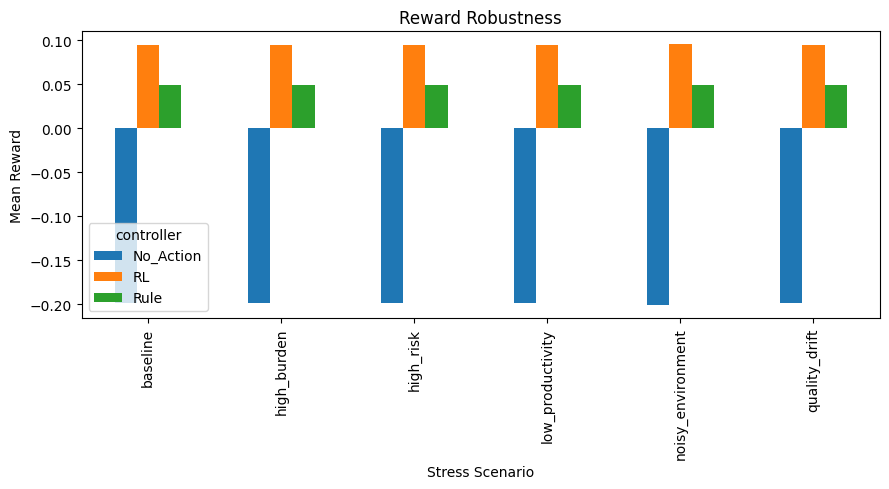

In [7]:
reward_pivot = (
    stress_results
    .pivot(
        index="scenario",
        columns="controller",
        values="reward"
    )
)

display(reward_pivot.round(3))

reward_pivot.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Reward Robustness")
plt.xlabel("Stress Scenario")
plt.ylabel("Mean Reward")
plt.tight_layout()
plt.show()

## Section 7 — Productivity robustness

This section evaluates whether controllers can preserve productivity
under adverse conditions.

Loss of productivity is one of the most important risks in manufacturing.

controller,No_Action,RL,Rule
scenario,,,
baseline,0.067,0.085,0.263
high_burden,0.067,0.085,0.263
high_risk,0.067,0.085,0.263
low_productivity,0.053,0.068,0.210
noisy_environment,0.067,0.085,0.263
quality_drift,0.067,0.085,0.263


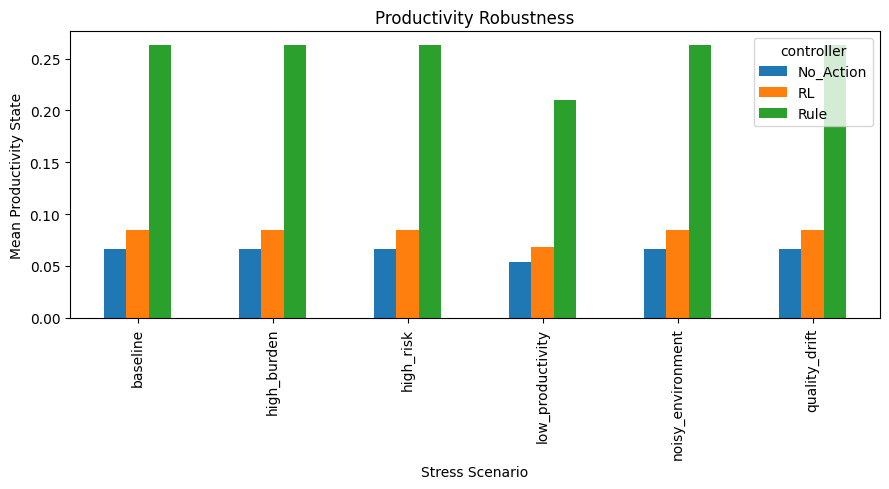

In [8]:
prod_pivot = (
    stress_results
    .pivot(
        index="scenario",
        columns="controller",
        values="productivity_state"
    )
)

display(prod_pivot.round(3))

prod_pivot.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Productivity Robustness")
plt.xlabel("Stress Scenario")
plt.ylabel("Mean Productivity State")
plt.tight_layout()
plt.show()

## Section 8 — Quality robustness

Product quality is evaluated using glycosylation metrics.

Controllers that preserve quality under stress are more valuable
for therapeutic manufacturing.

controller,No_Action,RL,Rule
scenario,,,
baseline,0.707,0.732,0.707
high_burden,0.707,0.732,0.707
high_risk,0.707,0.732,0.707
low_productivity,0.707,0.732,0.707
noisy_environment,0.707,0.732,0.707
quality_drift,0.601,0.622,0.601


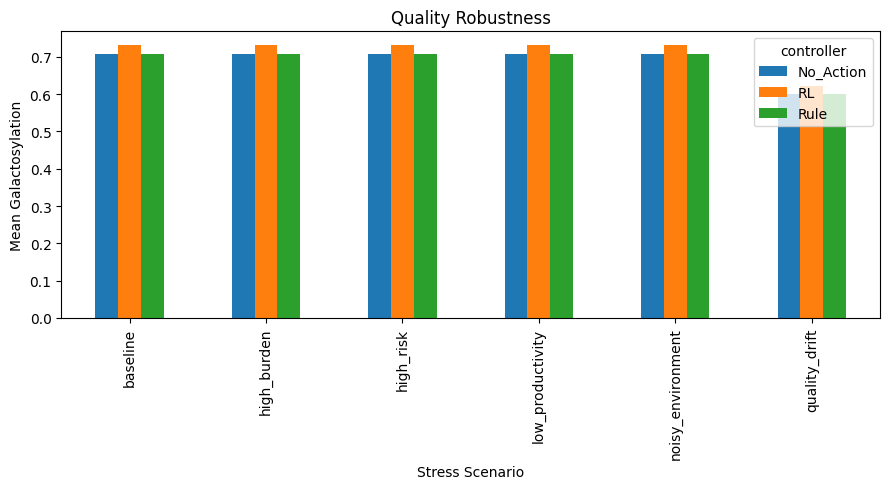

In [9]:
quality_pivot = (
    stress_results
    .pivot(
        index="scenario",
        columns="controller",
        values="galactosylation"
    )
)

display(quality_pivot.round(3))

quality_pivot.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Quality Robustness")
plt.xlabel("Stress Scenario")
plt.ylabel("Mean Galactosylation")
plt.tight_layout()
plt.show()

## Section 9 — Burden robustness

Integrated burden represents cellular strain.

Lower burden generally indicates healthier and more sustainable
production states.

controller,No_Action,RL,Rule
scenario,,,
baseline,0.286,0.175,0.298
high_burden,0.372,0.228,0.387
high_risk,0.286,0.175,0.298
low_productivity,0.286,0.175,0.298
noisy_environment,0.286,0.175,0.298
quality_drift,0.286,0.175,0.298


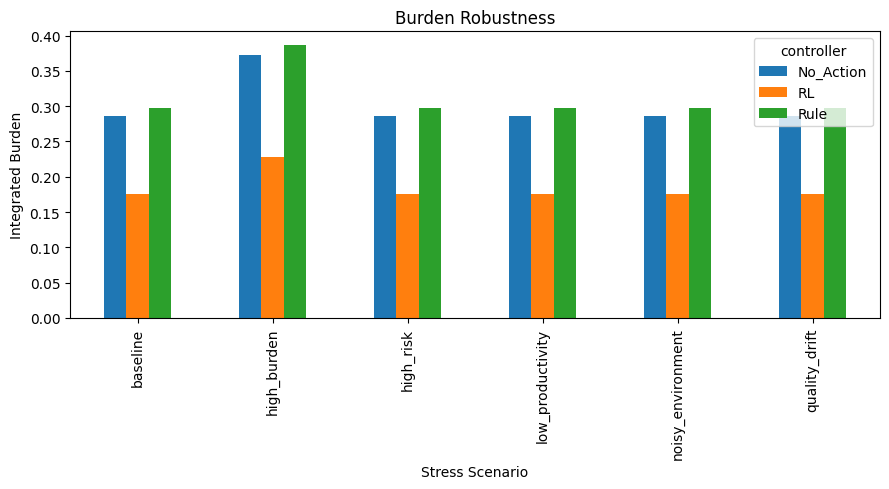

In [10]:
burden_pivot = (
    stress_results
    .pivot(
        index="scenario",
        columns="controller",
        values="integrated_burden"
    )
)

display(burden_pivot.round(3))

burden_pivot.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Burden Robustness")
plt.xlabel("Stress Scenario")
plt.ylabel("Integrated Burden")
plt.tight_layout()
plt.show()

## Section 10 — Failure-risk robustness

This metric estimates probability of entering unstable or failed
cellular states.

Lower values are preferred.

controller,No_Action,RL,Rule
scenario,,,
baseline,0.324,0.171,0.261
high_burden,0.324,0.171,0.261
high_risk,0.453,0.239,0.365
low_productivity,0.324,0.171,0.261
noisy_environment,0.324,0.171,0.261
quality_drift,0.324,0.171,0.261


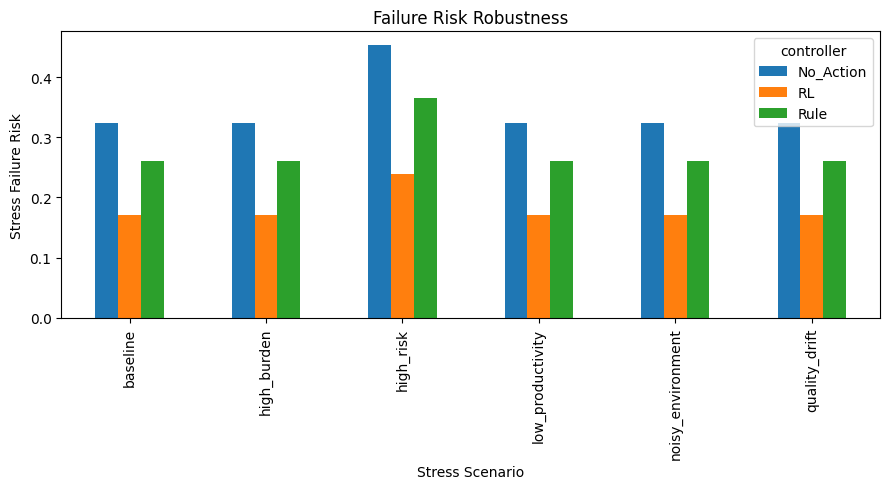

In [11]:
risk_pivot = (
    stress_results
    .pivot(
        index="scenario",
        columns="controller",
        values="stress_failure_risk"
    )
)

display(risk_pivot.round(3))

risk_pivot.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Failure Risk Robustness")
plt.xlabel("Stress Scenario")
plt.ylabel("Stress Failure Risk")
plt.tight_layout()
plt.show()

## Section 11 — Robustness scorecard

Multiple performance metrics are combined into a single robustness score.

Higher scores indicate stronger overall resilience.

In [12]:
scorecard = (
    stress_results
    .groupby("controller")
    [
        [
            "reward",
            "productivity_state",
            "galactosylation"
        ]
    ]
    .mean()
    .round(3)
)

display(scorecard)

,reward,productivity_state,galactosylation
controller,,,
No_Action,-0.199,0.065,0.690
RL,0.095,0.082,0.714
Rule,0.049,0.254,0.690


## Section 12 — Deployment recommendation

The final recommendation identifies the controller that performs
most consistently across all stress scenarios.

This controller becomes the preferred deployment candidate.

In [13]:
winner = (
    stress_results
    .groupby("controller")["reward"]
    .mean()
    .sort_values(ascending=False)
)

display(winner)

print("Recommended controller:")
print(winner.index[0])

controller
RL           0.094512
Rule         0.049161
No_Action   -0.199170
Name: reward, dtype: float64

Recommended controller:
RL


## Section 13 — Export robustness results

Robustness outputs are exported for downstream notebooks.

Future notebooks will use these datasets to evaluate controller
reliability and support autonomous decision making.

In [14]:
export_dir = (
    ROOT /
    "data/synthetic/digital_twin"
)

stress_results.to_csv(
    export_dir /
    "notebook17_stress_results_5000_legacy.csv",
    index=False
)

scorecard.to_csv(
    export_dir /
    "notebook17_robustness_scorecard_5000_legacy.csv"
)

print("Notebook17 exports saved.")

Notebook17 exports saved.


Notebook17 evaluated robustness of the learned RL controller under
simulated process perturbations.

Key outcomes:

- stress-test environments generated
- controller robustness quantified
- reward stability measured
- productivity resilience evaluated
- quality robustness assessed
- burden and risk analyzed
- deployment recommendation generated

A controller that remains effective under stress is significantly
more valuable than one that only performs well under ideal conditions.

This notebook moves the digital twin closer to realistic deployment.

# References

---

## Reinforcement Learning

### Sutton RS, Barto AG (2018)

**Reinforcement Learning: An Introduction (2nd Edition)**

MIT Press.

This is the foundational textbook for reinforcement learning and introduces:

- Markov Decision Processes (MDPs)
- Q-learning
- Temporal Difference Learning
- Policy Optimization

Reference:

Sutton, R. S., & Barto, A. G. (2018).
*Reinforcement Learning: An Introduction* (2nd ed.).
MIT Press.

https://www.andrew.cmu.edu/course/10-703/textbook/BartoSutton.pdf

---

## Offline Reinforcement Learning

### Levine N et al. (2020)

**Offline Reinforcement Learning: Tutorial, Review, and Perspectives on Open Problems**

This review summarizes modern offline RL methods where learning occurs from previously collected trajectories instead of active experimentation.

Reference:

Levine, N., Kumar, A., Tucker, G., & Fu, J. (2020).

*Offline Reinforcement Learning: Tutorial, Review, and Perspectives on Open Problems.*

arXiv:2005.01643

DOI:

10.48550/arXiv.2005.01643

https://arxiv.org/abs/2005.01643

---

## Digital Twins

### Tao F et al. (2019)

**Digital Twin Driven Smart Manufacturing**

This work provides the conceptual framework for digital twins in industrial systems.

Reference:

Tao, F., Zhang, H., Liu, A., & Nee, A. Y. C. (2019).

*Digital Twin in Industry: State-of-the-Art.*

IEEE Transactions on Industrial Informatics.

DOI:

10.1109/TII.2018.2873186

---

## Process Analytical Technology (PAT)

### FDA Guidance for Industry (2004)

**PAT — A Framework for Innovative Pharmaceutical Development, Manufacturing, and Quality Assurance**

This document established the PAT paradigm used throughout modern bioprocess monitoring and control.

Reference:

U.S. Food and Drug Administration (FDA).

*PAT — A Framework for Innovative Pharmaceutical Development, Manufacturing, and Quality Assurance.*

2004.

https://www.fda.gov

---

## CHO Cell Engineering

### Wurm FM (2004)

**Production of Recombinant Protein Therapeutics in Cultivated Mammalian Cells**

Reference:

Wurm, F. M. (2004).

*Production of Recombinant Protein Therapeutics in Cultivated Mammalian Cells.*

Nature Biotechnology.

DOI:

10.1038/nbt1026

---

### Kim JY et al. (2012)

**CHO Cells in Biotechnology for Production of Recombinant Proteins**

Reference:

Kim, J. Y.,
Kim, Y. G.,
Lee, G. M.

(2012)

*CHO Cells in Biotechnology for Production of Recombinant Proteins.*

Current Opinion in Biotechnology.

DOI:

10.1016/j.copbio.2011.10.002

---

## Autonomous Bioprocessing

### Ruffieux PA et al.

**Autonomous Control and Optimization in Biomanufacturing**

This body of work motivates self-driving bioprocess systems and closed-loop process optimization.

Relevant themes:

- automated experimentation
- adaptive process control
- digital twins
- reinforcement learning
- self-driving laboratories

---

## Relation to This Project

Notebook17 combines concepts from:

- CHO cell engineering
- process analytical technology (PAT)
- digital twins
- offline reinforcement learning
- autonomous bioprocessing

to evaluate whether a learned controller remains robust under realistic process perturbations before deployment into future self-driving laboratory workflows.